In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.Collecting tensorflow
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 1.7/331.8 MB 35.5 MB/s eta 0:00:10
   ---------------------------------------- 4.0/331.8 MB 42.4 MB/s eta 0:00:08
    --------------------------------------- 6.0/331.8 MB 42.3 MB/s eta 0:00:08
    --------------------------------------- 8.3/331.8 MB 44.1 MB/s eta 0:00:08
   - -------------------------------------- 10.4/331.8 MB 46.7 MB/s eta 0:00:07
   - -------------------------------------- 12.5/331.8 MB 46.7 MB/s eta 0:00:07
   - -------------------------------------- 14.7/331.8 MB 46.7 MB/s eta 0:00:07
   -- ------------------------------------- 16.9/331.8 MB 46.9 MB/s eta 0:00:07
   -- ------------------------------------- 19.2/331.8 MB 46.9 MB/s eta 0:00:07
   -- ------------------------------------- 21.9/331.8 MB 46.7 MB/s eta 0:00:07
   -- ------------------------------------- 24

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.1 which is incompatible.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


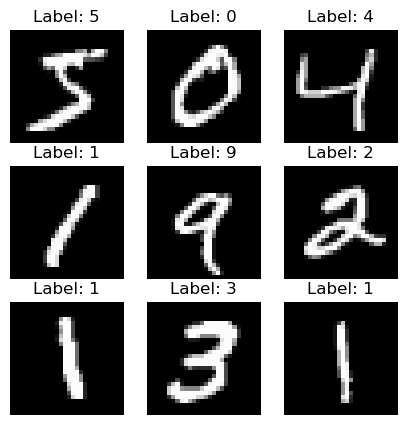

C:\Users\zgas\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9212 - loss: 0.2760 - val_accuracy: 0.9610 - val_loss: 0.1402
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9642 - loss: 0.1212 - val_accuracy: 0.9710 - val_loss: 0.0991
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9757 - loss: 0.0813 - val_accuracy: 0.9730 - val_loss: 0.0953
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9816 - loss: 0.0600 - val_accuracy: 0.9732 - val_loss: 0.0928
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9858 - loss: 0.0462 - val_accuracy: 0.9772 - val_loss: 0.0866
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9740 - loss: 0.0864
Test accuracy : 0.9739999771118164


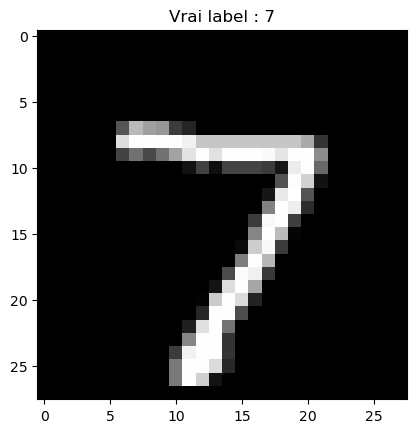

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Prédiction du réseau : 7


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Charger et préparer MNIST
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

# -----------------------------
# 2. Visualiser quelques images
# -----------------------------
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# -----------------------------
# 3. Construire le réseau
# -----------------------------
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

# -----------------------------
# 4. Compiler
# -----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 5. Entraîner
# -----------------------------
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

# -----------------------------
# 6. Évaluer
# -----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy :", test_acc)

# -----------------------------
# 7. Tester un exemple
# -----------------------------
index = 0  # changer l'index si tu veux
image = x_test[index]

plt.imshow(image, cmap='gray')
plt.title(f"Vrai label : {y_test[index]}")
plt.show()

prediction = model.predict(image.reshape(1, 28, 28))
print("Prédiction du réseau :", np.argmax(prediction))


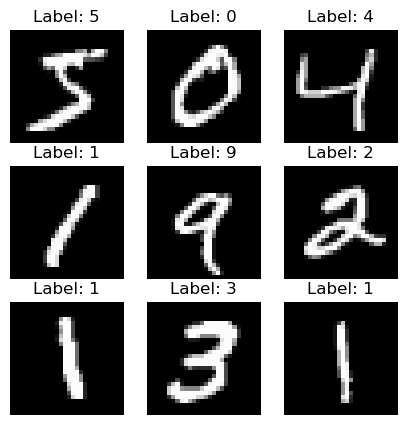

C:\Users\zgas\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9533 - loss: 0.1523 - val_accuracy: 0.9835 - val_loss: 0.0565
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9846 - loss: 0.0501 - val_accuracy: 0.9883 - val_loss: 0.0442
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9890 - loss: 0.0347 - val_accuracy: 0.9863 - val_loss: 0.0471
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9915 - loss: 0.0264 - val_accuracy: 0.9890 - val_loss: 0.0472
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9936 - loss: 0.0185 - val_accuracy: 0.9900 - val_loss: 0.0356
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9893 - loss: 0.0321
Test accuracy : 0.989300012588501


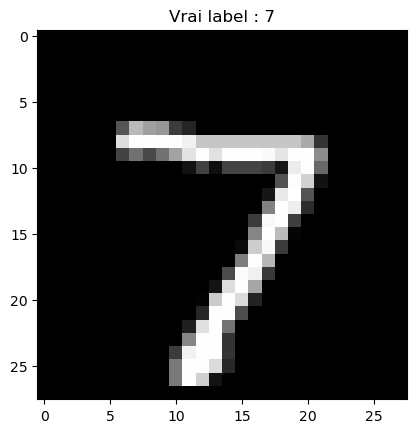

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Prédiction du réseau : 7


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Load and prepare MNIST
# -----------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0

# CNN expects shape (28,28,1) → add channel dimension
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# -----------------------------
# 2. Visualize some images
# -----------------------------
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# -----------------------------
# 3. Build the CNN
# -----------------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

# -----------------------------
# 4. Compile the model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 5. Train the model
# -----------------------------
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

# -----------------------------
# 6. Evaluate on test data
# -----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy :", test_acc)

# -----------------------------
# 7. Predict on a single image
# -----------------------------
index = 0
image = x_test[index]

plt.imshow(image.reshape(28,28), cmap='gray')
plt.title(f"Vrai label : {y_test[index]}")
plt.show()

prediction = model.predict(image.reshape(1,28,28,1))
print("Prédiction du réseau :", np.argmax(prediction))
